# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [58]:
import pandas as pd
import sklearn.datasets
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import DecisionBoundaryDisplay

![Iris Flowers](../assets/iris_flowers.png)

### Step 1.a Load the data

In [59]:
iris = sklearn.datasets.load_iris(as_frame=True)
df = iris.frame

### Step 2.a Assign variables `X` to the features and `y` to the target

In [60]:
X = iris.data   
y = iris.target  

### Step 2.b print the type of each

In [61]:
print(f"X type: {type(X)}, y type: {type(y)}")

X type: <class 'pandas.DataFrame'>, y type: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [62]:
unique_species = iris.target_names
print(f"Species names: {unique_species}")

if y.dtype == 'int64' or y.dtype == 'object':
    print("Target is: Categorical (Classes)")
    print("Task is: Classification")
else:
    print("Target is: Numerical")
    print("Task is: Regression")

Species names: ['setosa' 'versicolor' 'virginica']
Target is: Categorical (Classes)
Task is: Classification


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [63]:
shape_X = X.shape
shape_y = y.shape

print(f"Number of samples and columns in X: {shape_X}")
print(f"Number of samples in y: {shape_y}")

Number of samples and columns in X: (150, 4)
Number of samples in y: (150,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [64]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

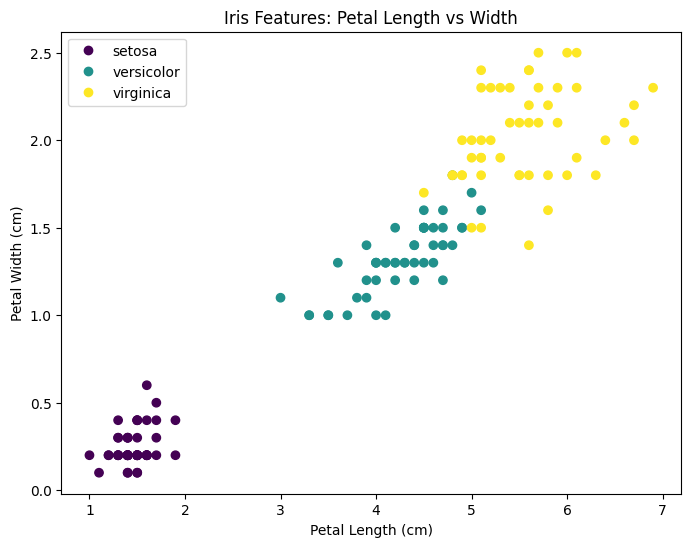

In [65]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X['petal length (cm)'], X['petal width (cm)'], c=y, cmap='viridis')

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Features: Petal Length vs Width')
plt.legend(handles=scatter.legend_elements()[0], labels=iris.target_names.tolist())
plt.show()

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [66]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]
X_petal = X[['petal length (cm)', 'petal width (cm)']]

print("Sepal features sample:")
print(X_sepal.head())

Sepal features sample:
   sepal length (cm)  sepal width (cm)
0                5.1               3.5
1                4.9               3.0
2                4.7               3.2
3                4.6               3.1
4                5.0               3.6


### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [67]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]

### Step 7. Initialize 2 `LogisticRegression` models

In [68]:
model_sepal = LogisticRegression()
model_petal = LogisticRegression()

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

In [69]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sepal, y, test_size=0.2, stratify=y, random_state=42
)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_petal, y, test_size=0.2, stratify=y, random_state=42
)

### Step 9.a Train both models

In [70]:
model_sepal.fit(X_train_s, y_train_s)

model_petal.fit(X_train_p, y_train_p)

print("Training completed for both models.")

Training completed for both models.


### Step 10. Evaluate and compare both models

In [71]:
accuracy_sepal = model_sepal.score(X_test_s, y_test_s)
accuracy_petal = model_petal.score(X_test_p, y_test_p)

print(f"Accuracy with Sepal features: {accuracy_sepal * 100:.2f}%")
print(f"Accuracy with Petal features: {accuracy_petal * 100:.2f}%")

Accuracy with Sepal features: 73.33%
Accuracy with Petal features: 96.67%


### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

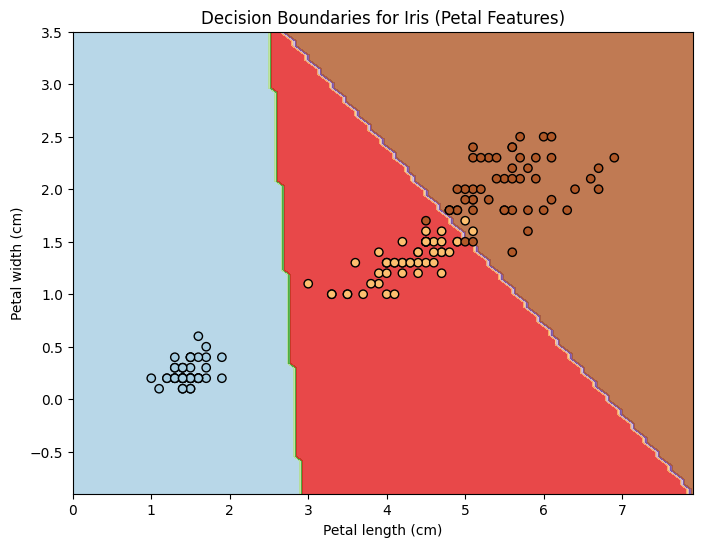

In [72]:
fig, ax = plt.subplots(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(
    model_petal,
    X_petal,
    response_method="predict",
    cmap=plt.cm.Paired,
    ax=ax,
    alpha=0.8
)
scatter = ax.scatter(
    X_petal.iloc[:, 0], 
    X_petal.iloc[:, 1], 
    c=y, 
    edgecolors='k', 
    cmap=plt.cm.Paired
)
ax.set_xlabel('Petal length (cm)')
ax.set_ylabel('Petal width (cm)')
ax.set_title('Decision Boundaries for Iris (Petal Features)')

plt.show()

### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

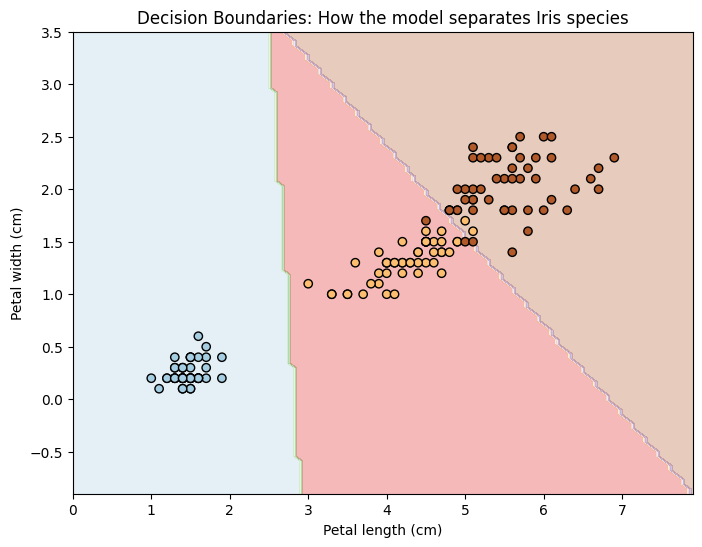

In [73]:
fig, ax = plt.subplots(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    model_petal,
    X_petal,
    response_method="predict",
    cmap=plt.cm.Paired,
    ax=ax,
    alpha=0.3 
)
plt.scatter(
    X_petal.iloc[:, 0], 
    X_petal.iloc[:, 1], 
    c=y, 
    edgecolors='k', 
    cmap=plt.cm.Paired
)
plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Decision Boundaries: How the model separates Iris species')
plt.show()